Se carga el archivo, se crea un dataframe "personas"

In [ ]:
import pandas as pd
personas = pd.read_csv('ingresos.csv')
print (personas.sample(frac=2/3, replace=True))

    edad  estudio  genero  tipo_trabajo  horas  ingreso
57    62       13       1             0      1        1
3     26       13       0             0     50        0
5     20       10       1             0     40        0
10    49        3       0             0     20        0
17    67       16       1             0     60        1
..   ...      ...     ...           ...    ...      ...
94    37        5       1             0     50        1
55    30       10       0             0     40        0
28    30        9       1             1     60        0
82    49        9       1             0     40        0
27    21       10       1             0     25        0

[67 rows x 6 columns]


Se eligen 3 elementos aleatorios de la lista y se devuelven los nombres de todas las columnas del Data frame tomando desde el inicio hasta la ultima columna

In [ ]:
from random import sample
print(personas.columns[:-1], "\n")
print(sample(list(set(personas.columns[:-1])), 3))

Index(['edad', 'estudio', 'genero', 'tipo_trabajo', 'horas'], dtype='object') 

['estudio', 'edad', 'genero']


Se crea y entrena un modelo de Random Forest para clasificar datos y evaluar rendimiento con un bosque de arboles de decicion para predicciones precisas donde cada arbol usa solo una parte de las variables, seleccionando todas las columnas exepto la ultima y calculando la exactitud del modelo usando los datos completos.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
bosque = RandomForestClassifier(n_estimators=100,
                                criterion="gini",
                                max_features="sqrt",
                                bootstrap=True,
                                max_samples=2/3,
                                oob_score=True)
bosque.fit(personas[personas.columns[:-1]].values, personas["ingreso"].values)
print(bosque.predict([[50,16,1,1,40]]))
print(bosque.score(personas[personas.columns[:-1]].values, personas["ingreso"].values))
print(bosque.oob_score_)

[1]
0.98
0.76


Se dibuja y muestra visualmente los arboles de decisión que forman parte del modelo Random Forest.

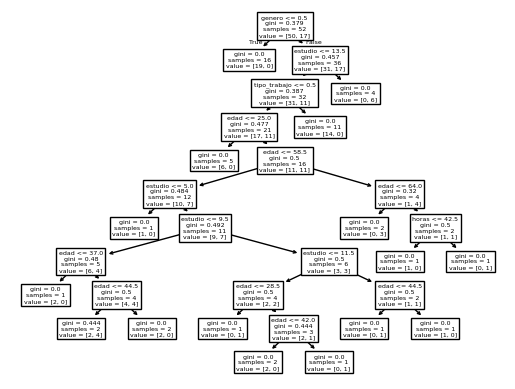

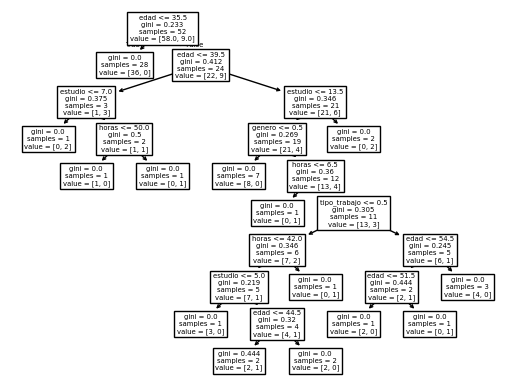

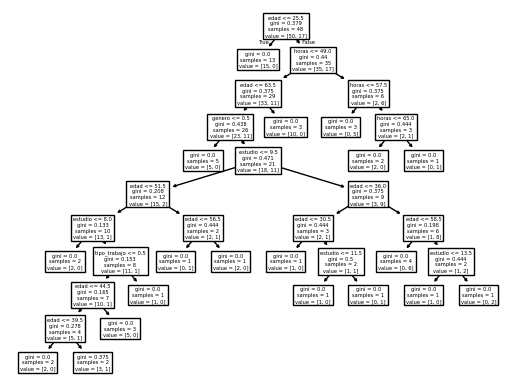

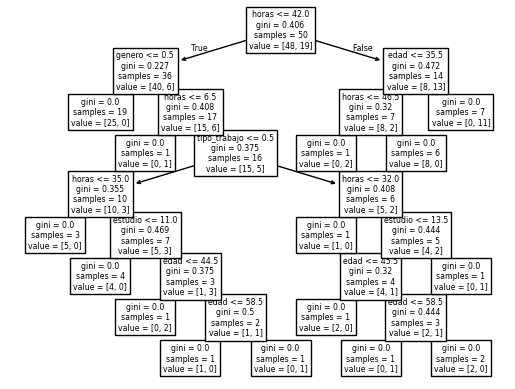

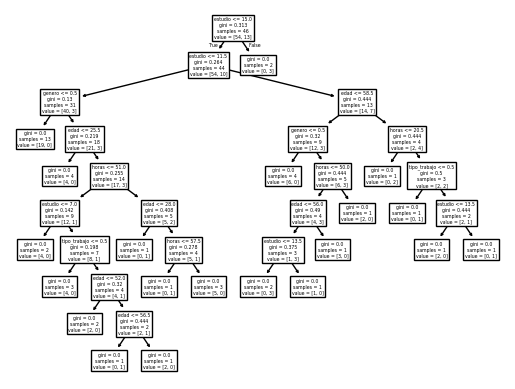

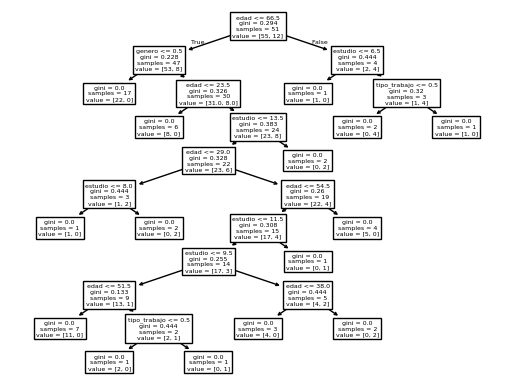

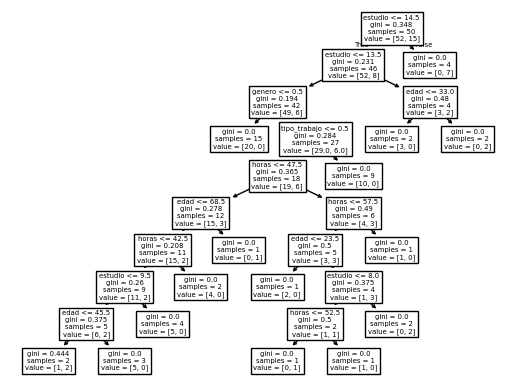

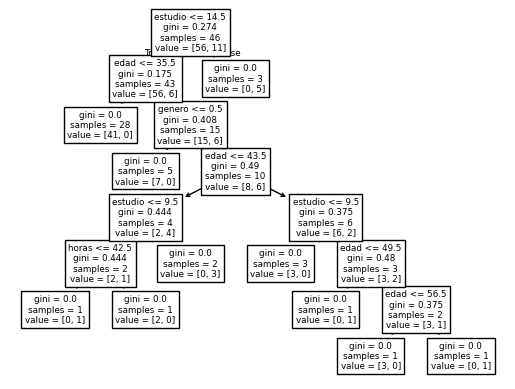

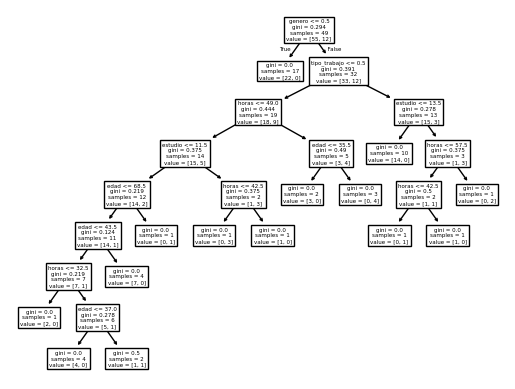

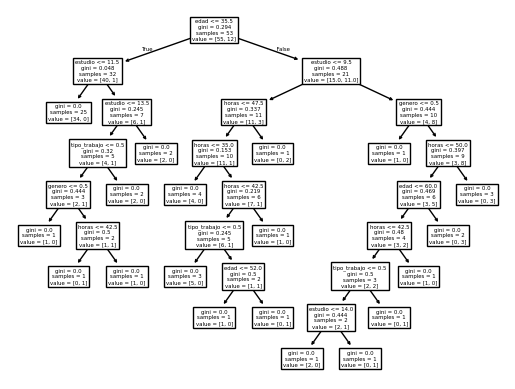

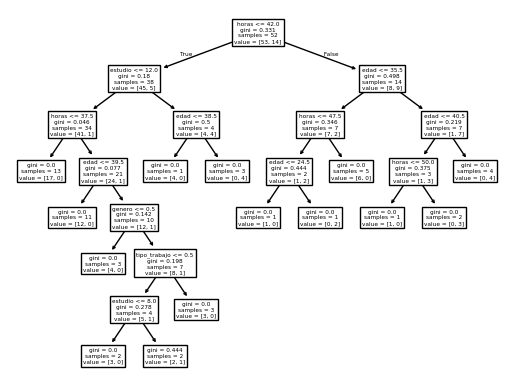

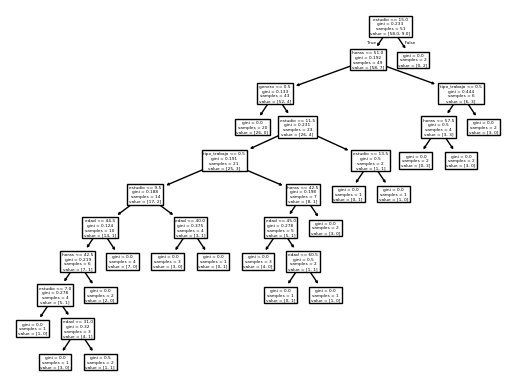

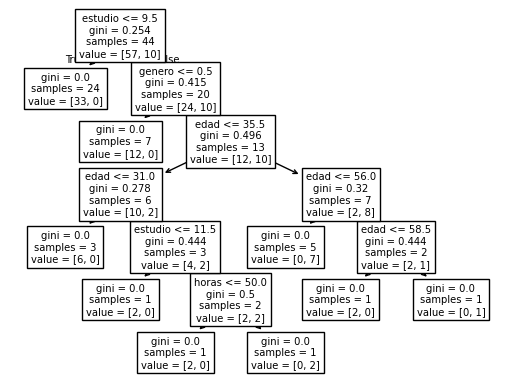

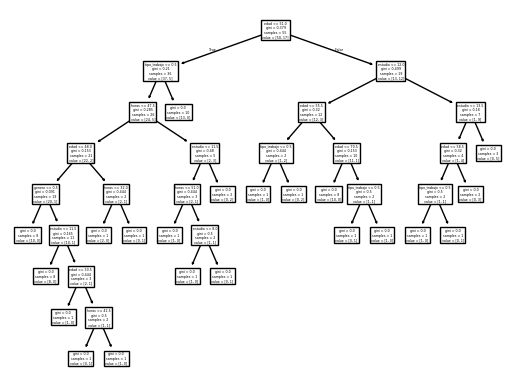

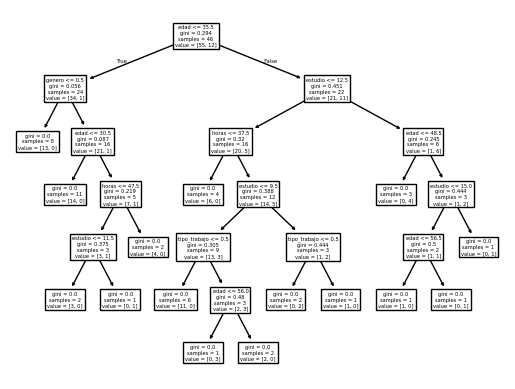

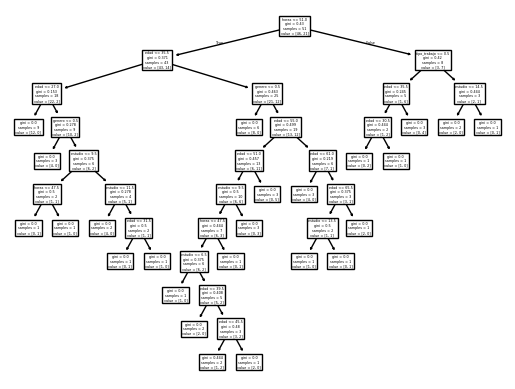

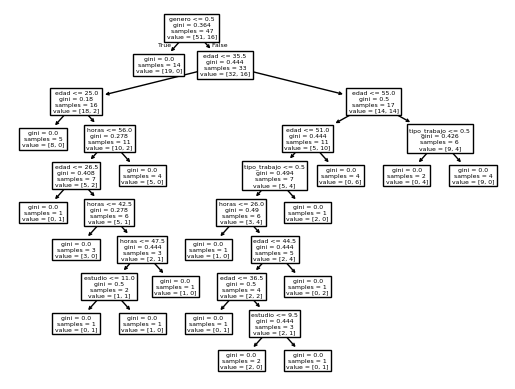

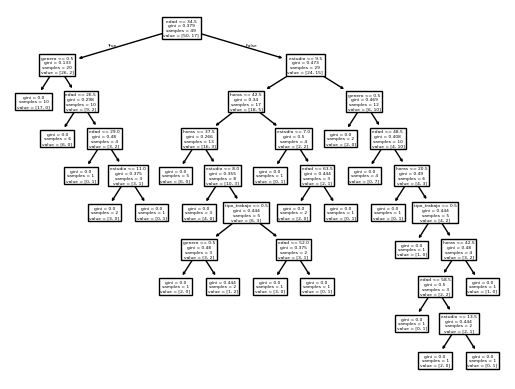

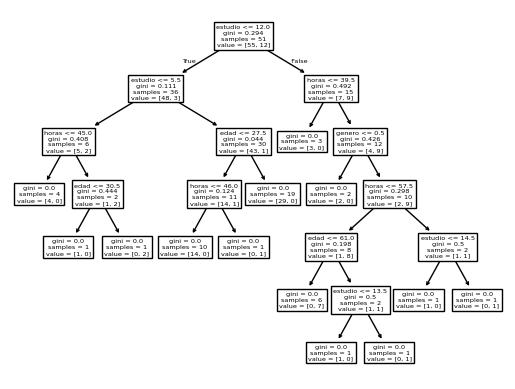

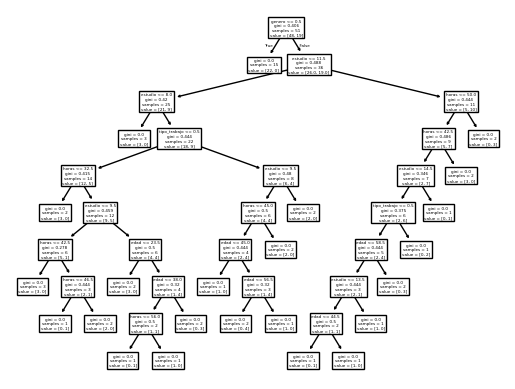

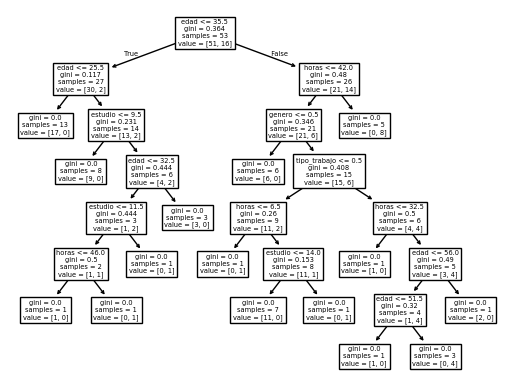

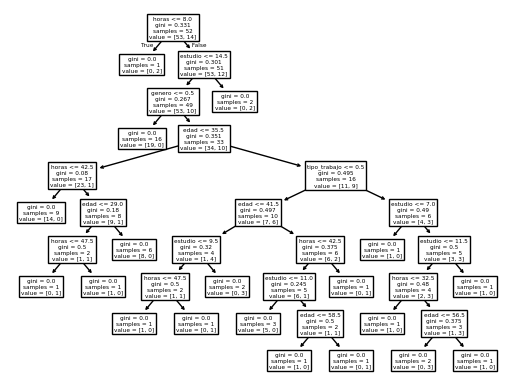

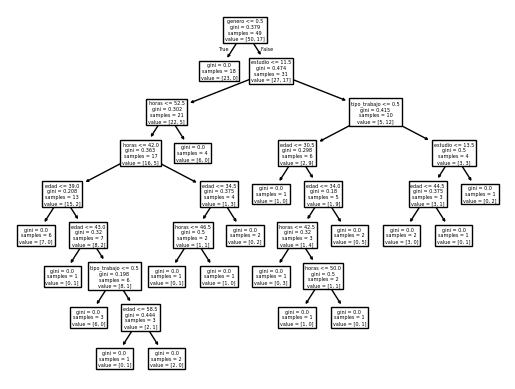

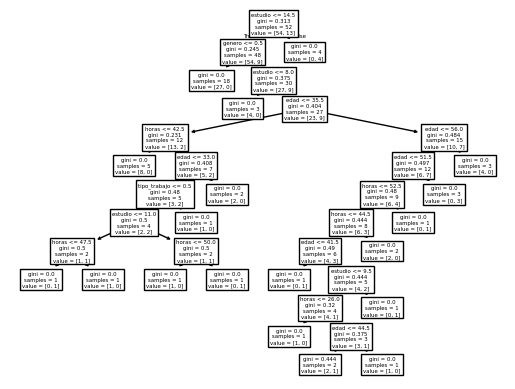

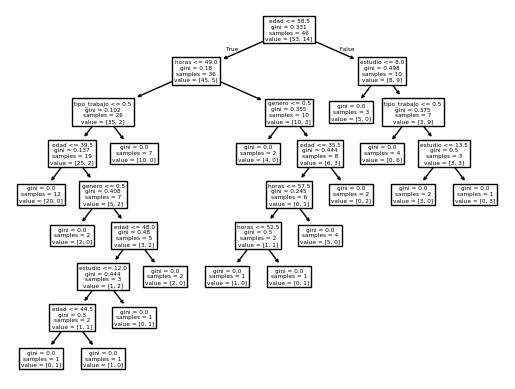

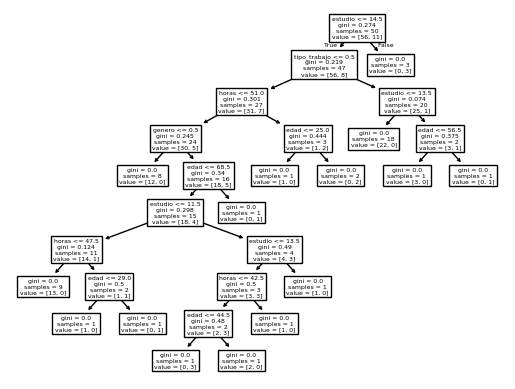

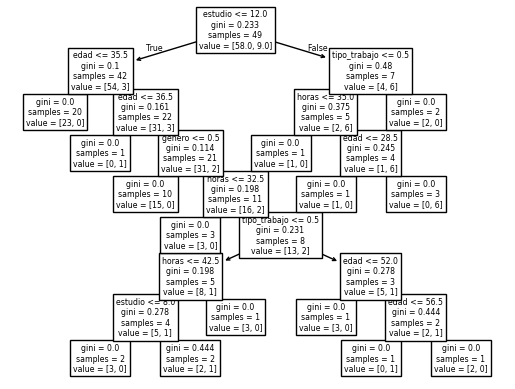

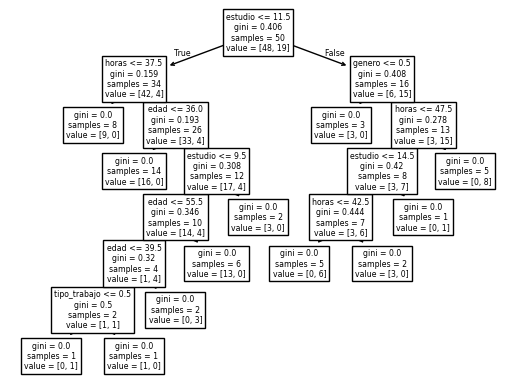

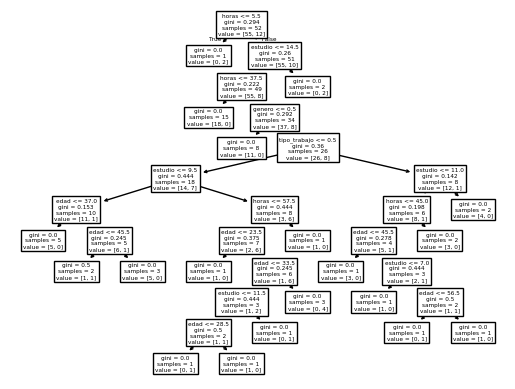

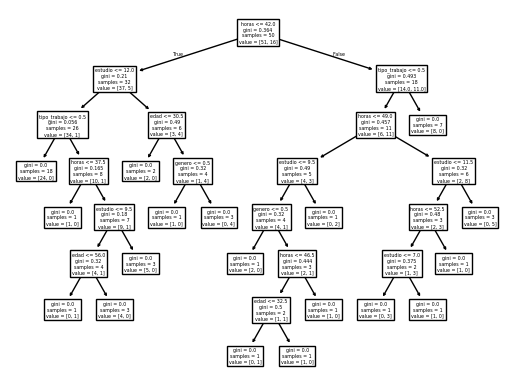

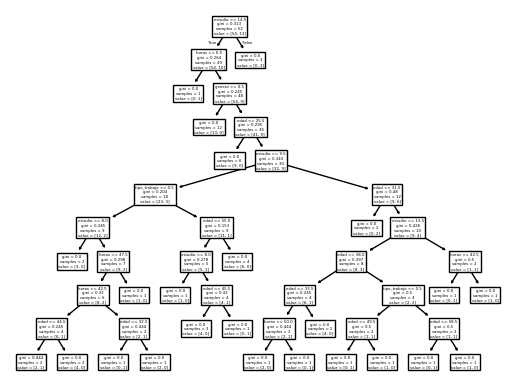

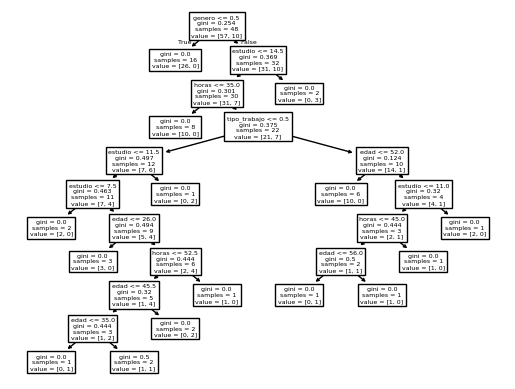

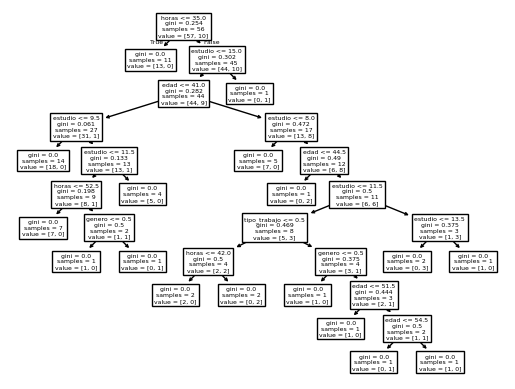

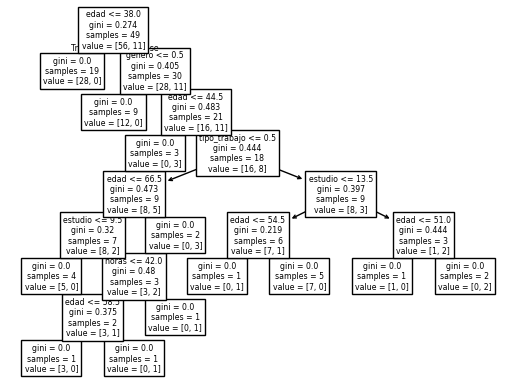

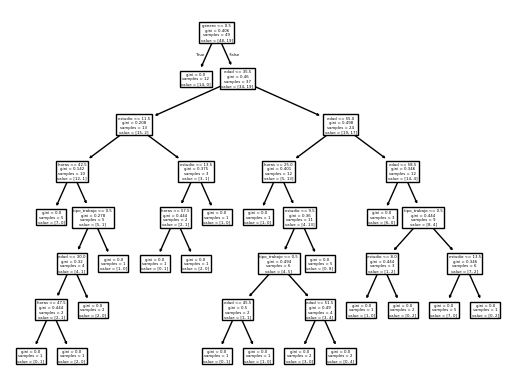

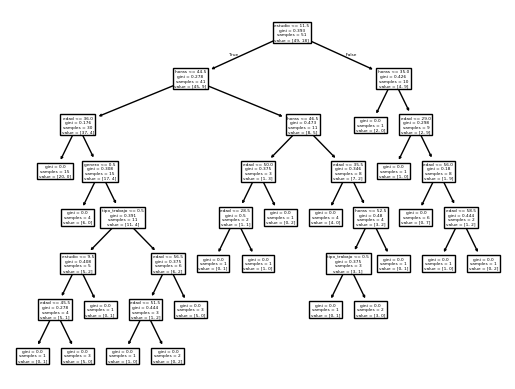

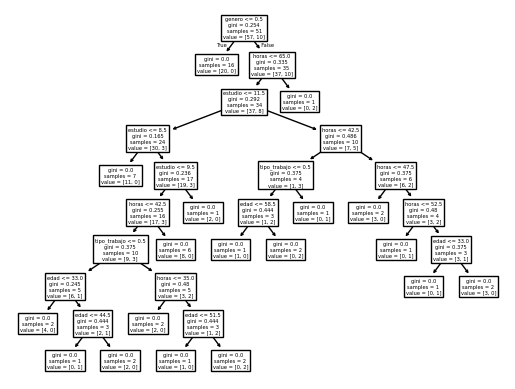

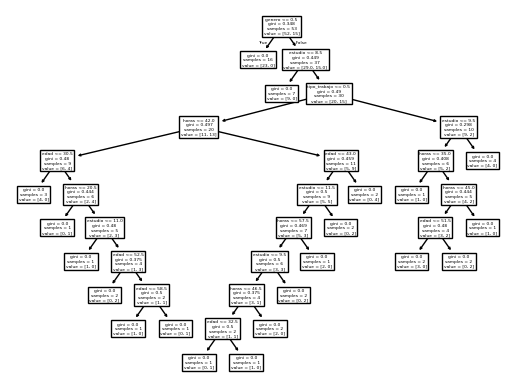

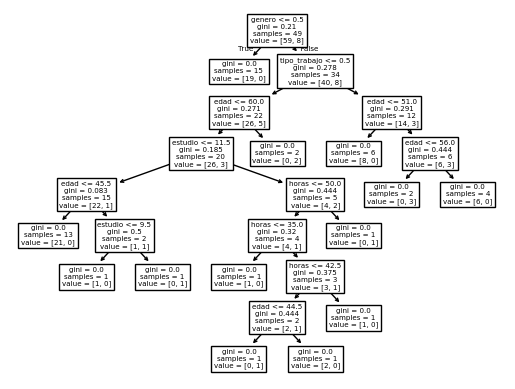

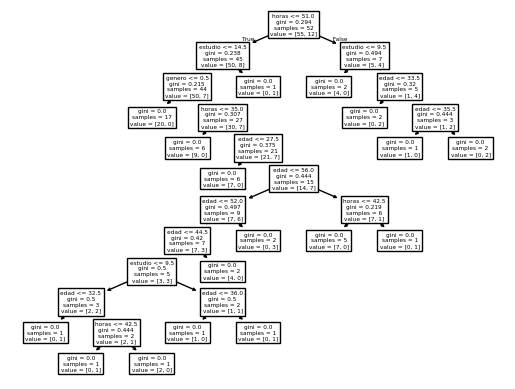

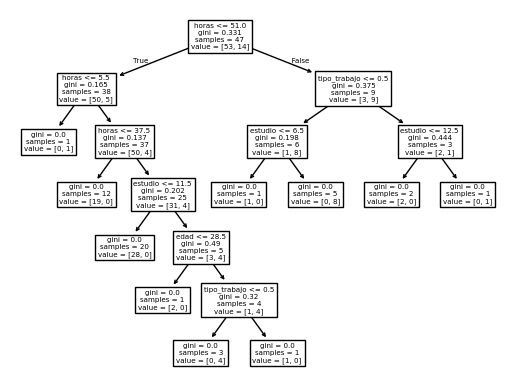

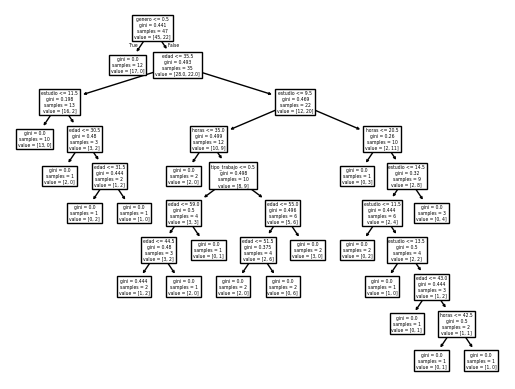

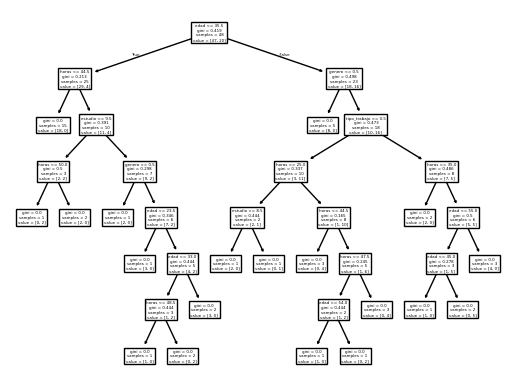

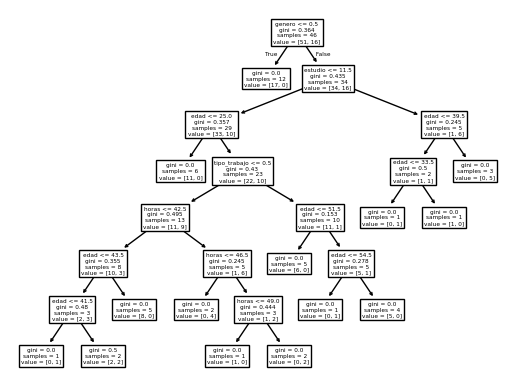

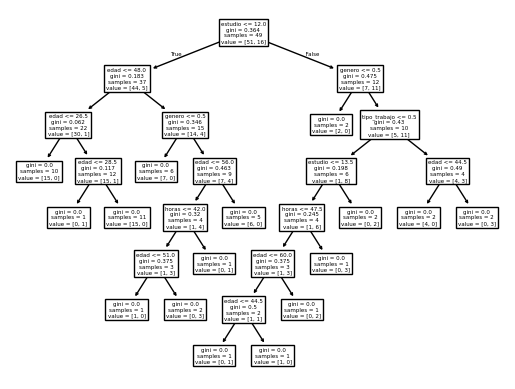

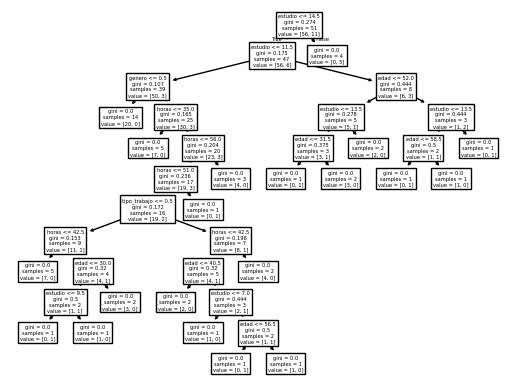

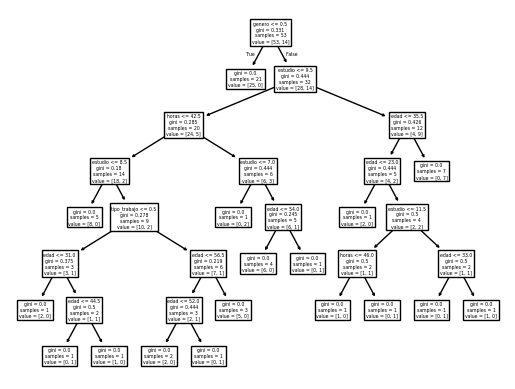

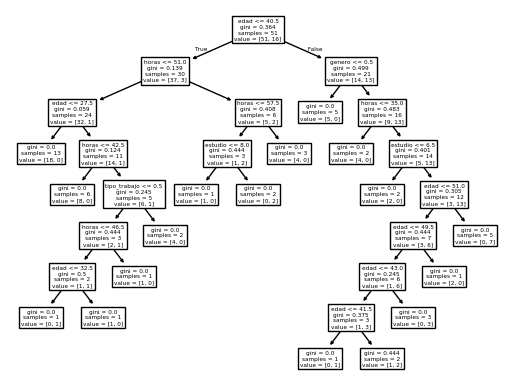

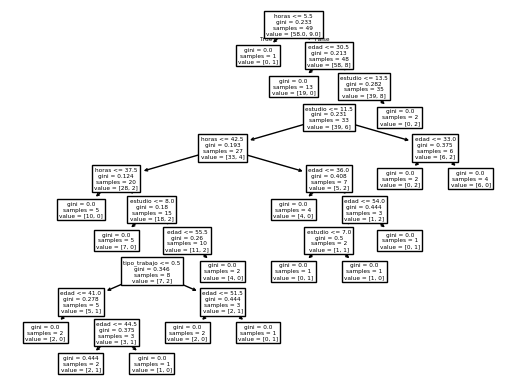

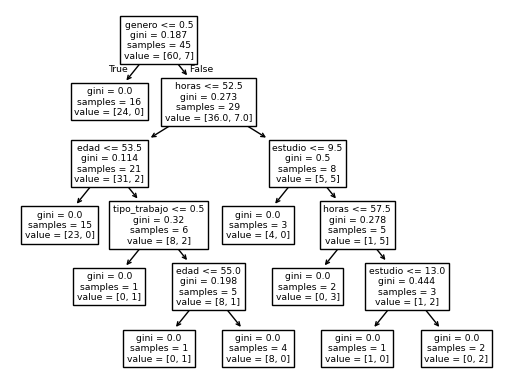

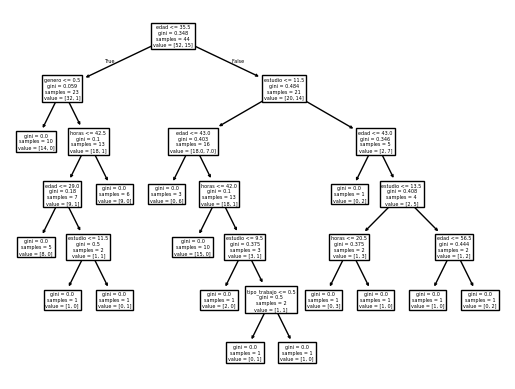

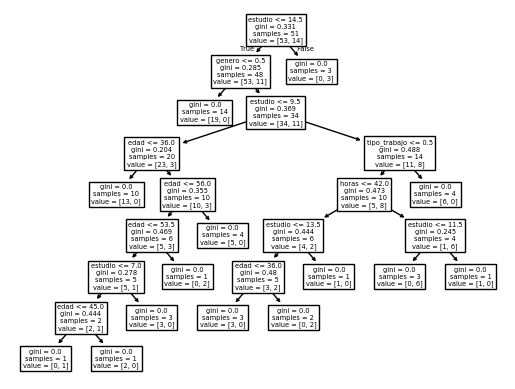

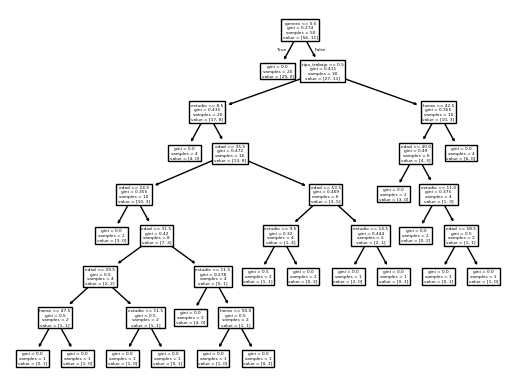

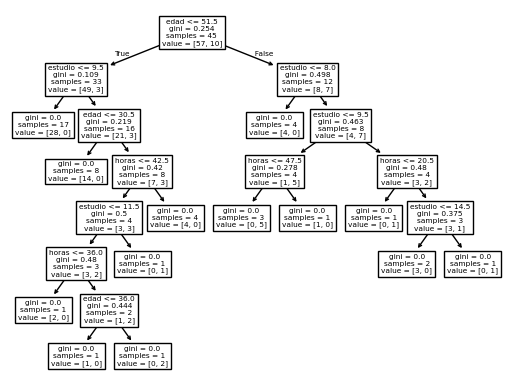

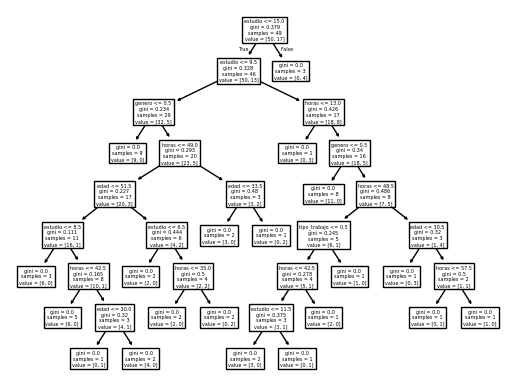

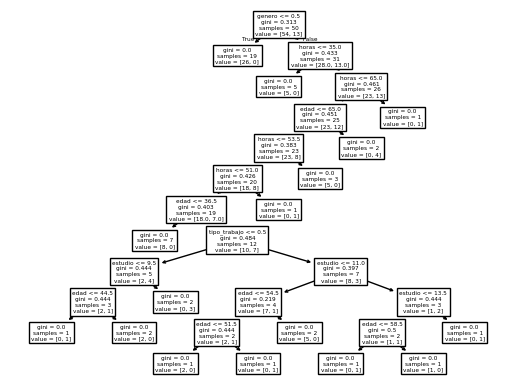

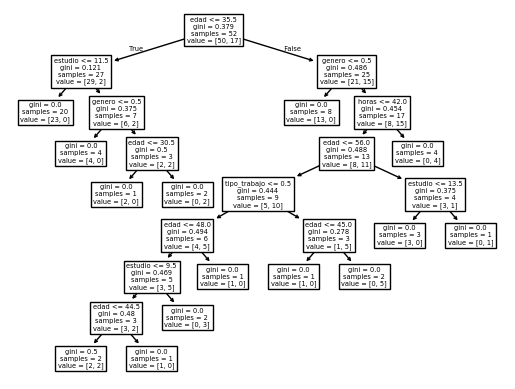

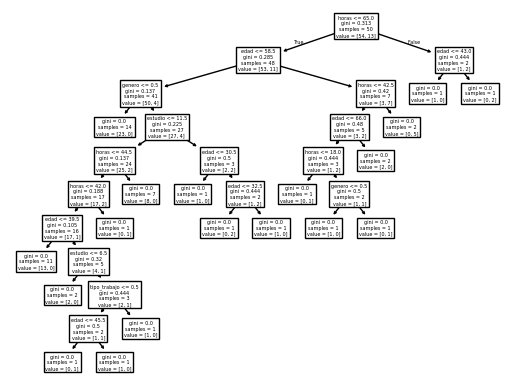

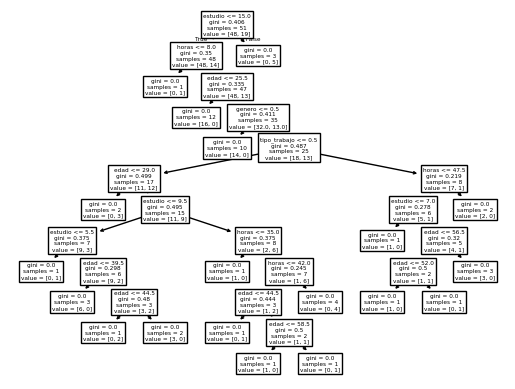

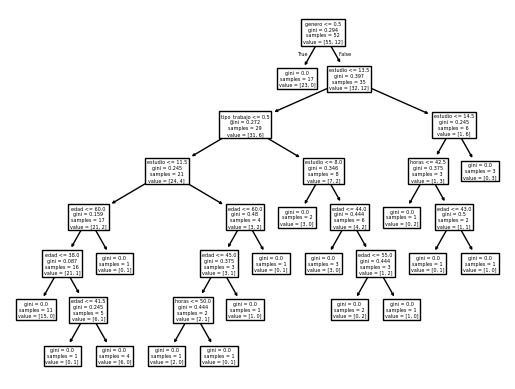

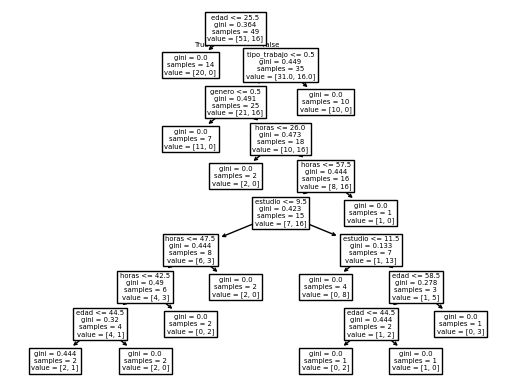

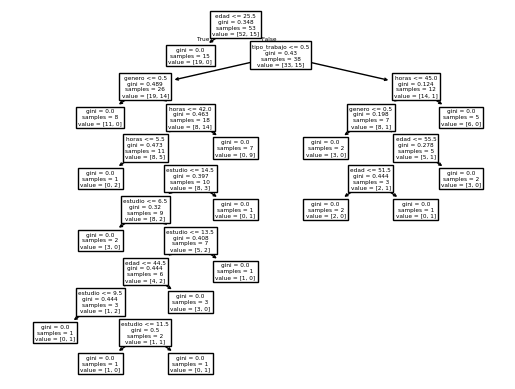

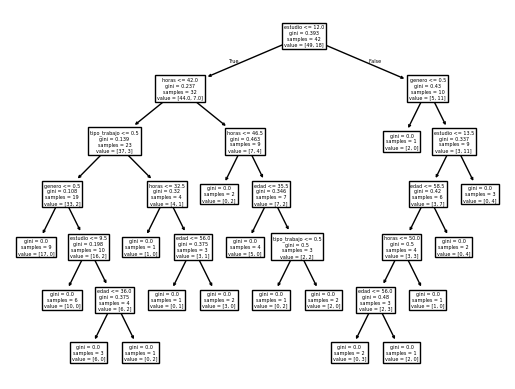

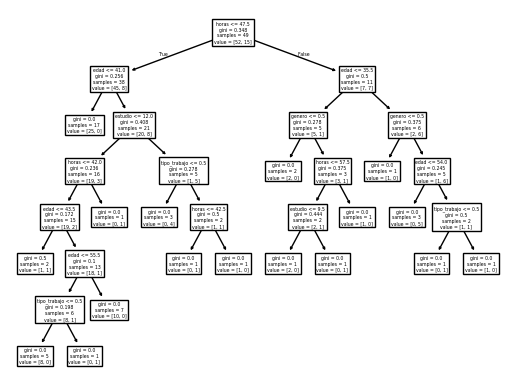

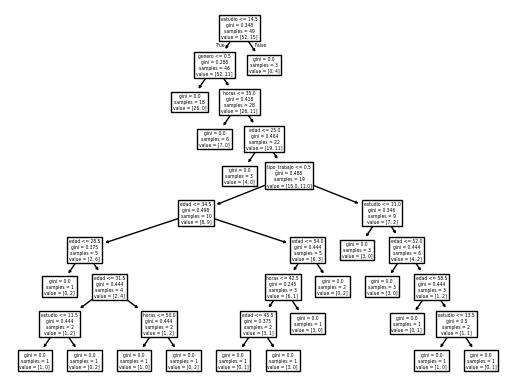

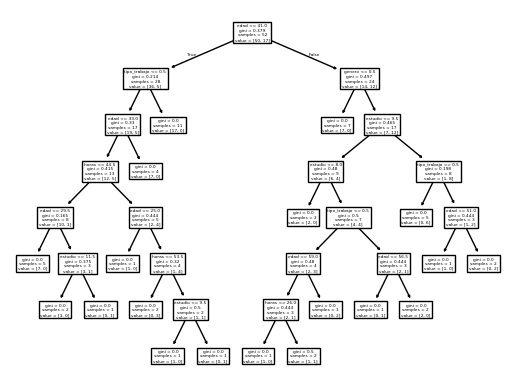

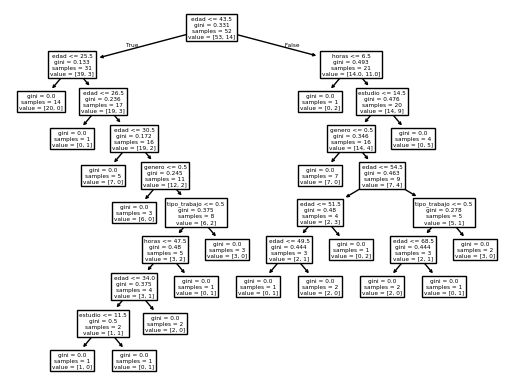

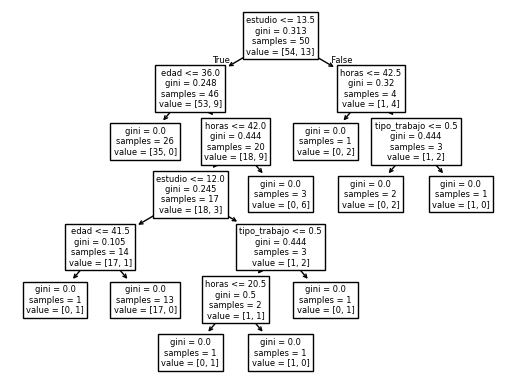

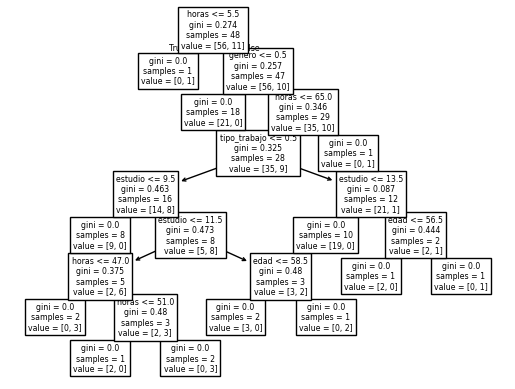

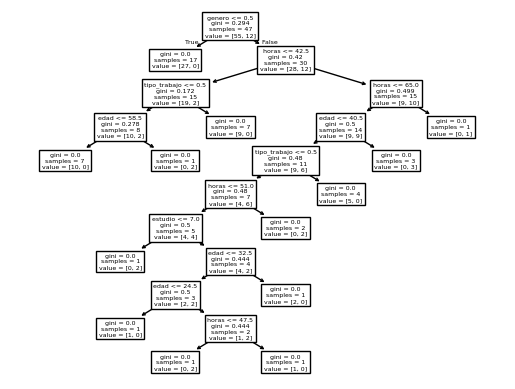

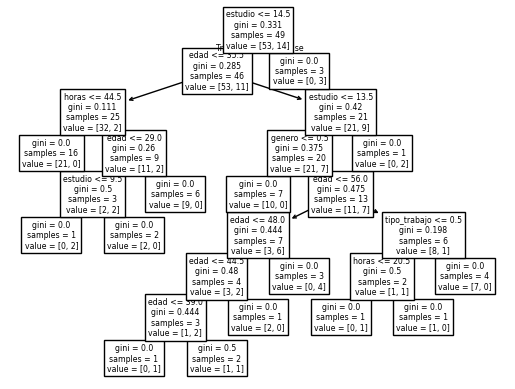

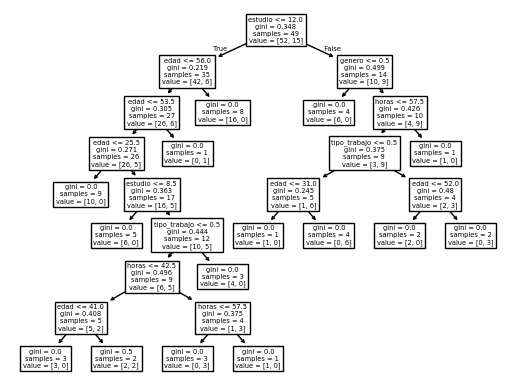

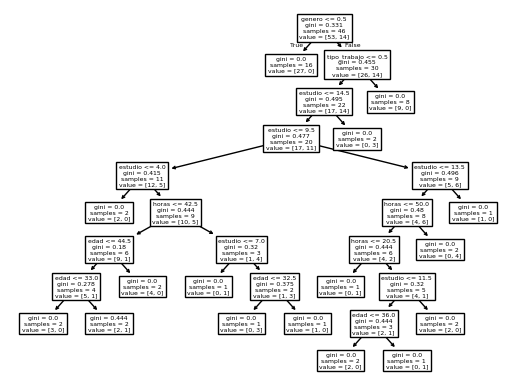

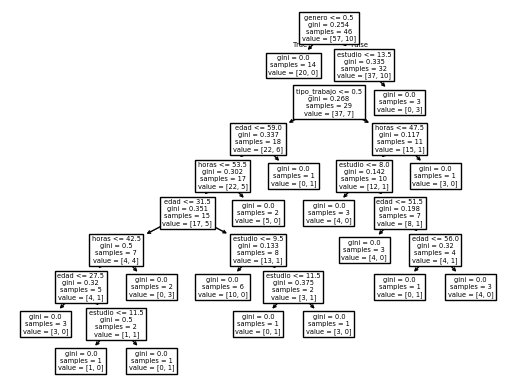

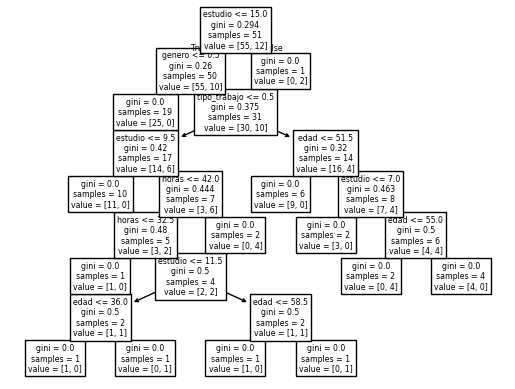

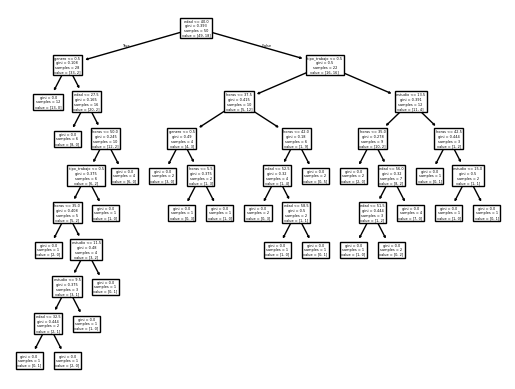

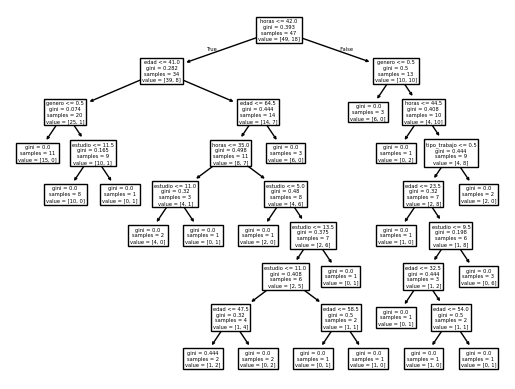

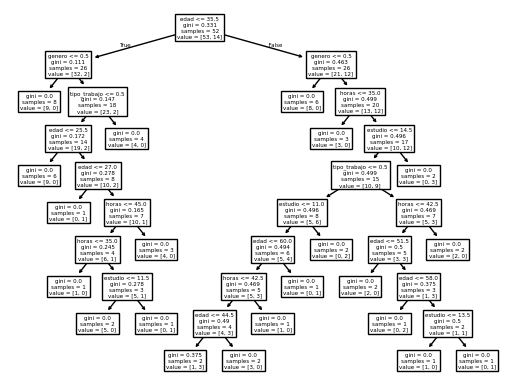

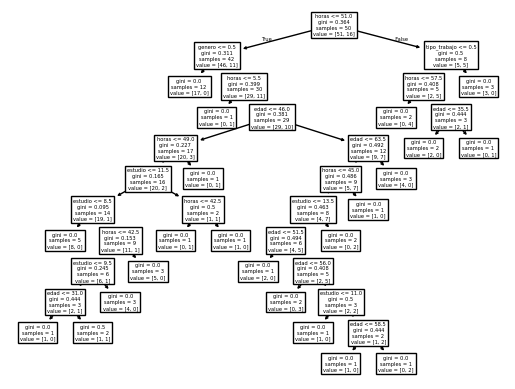

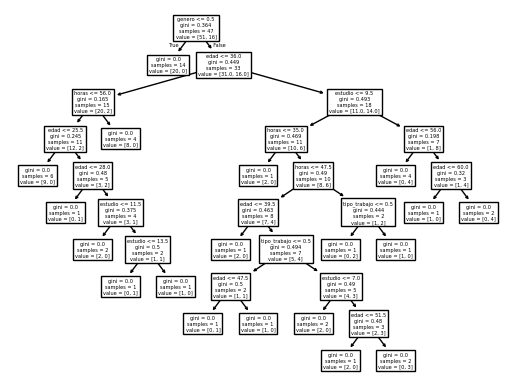

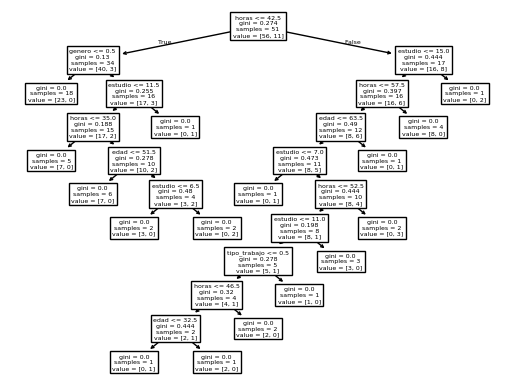

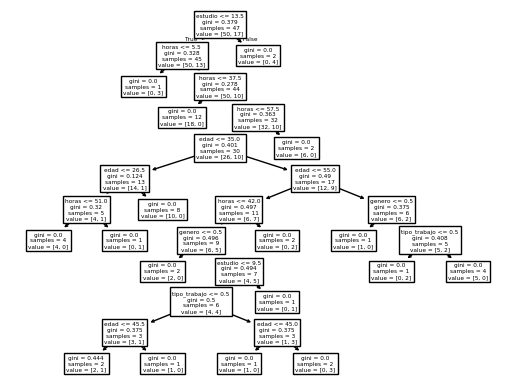

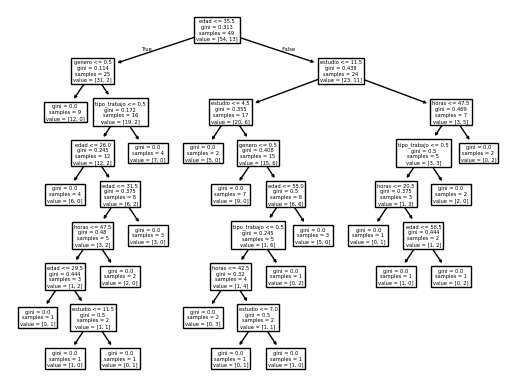

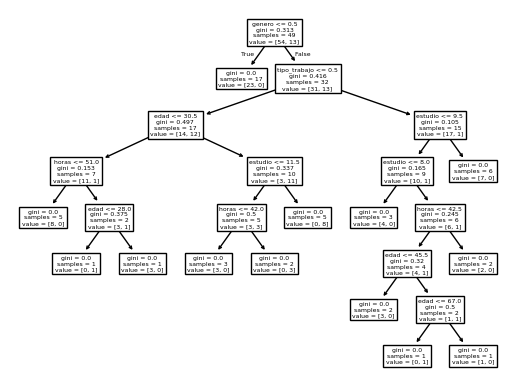

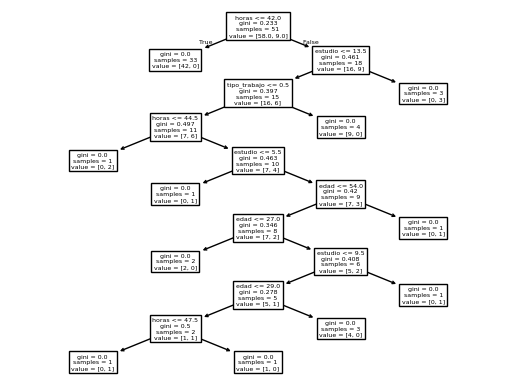

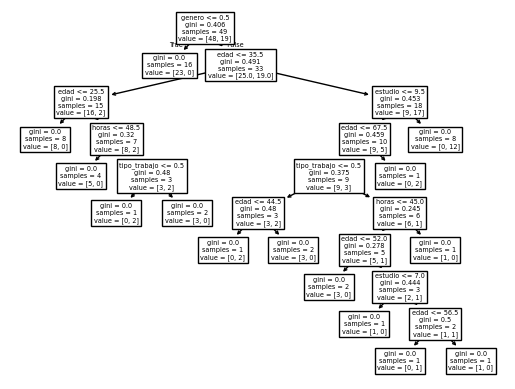

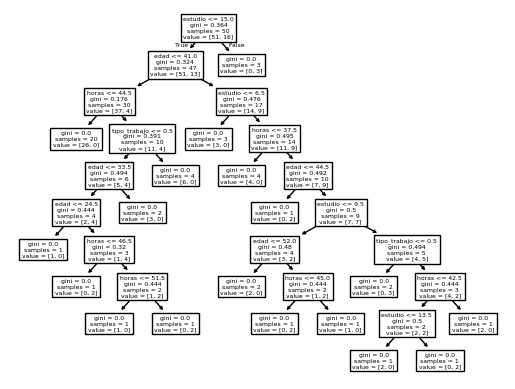

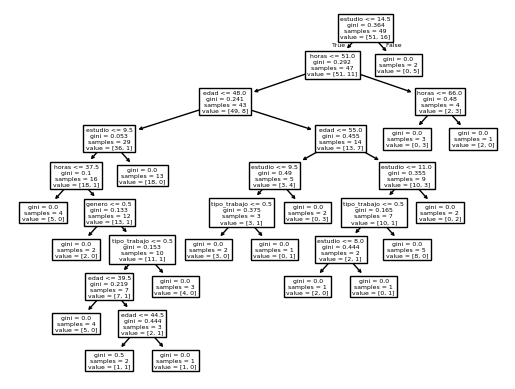

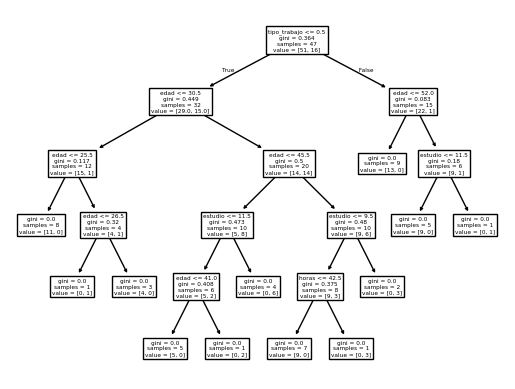

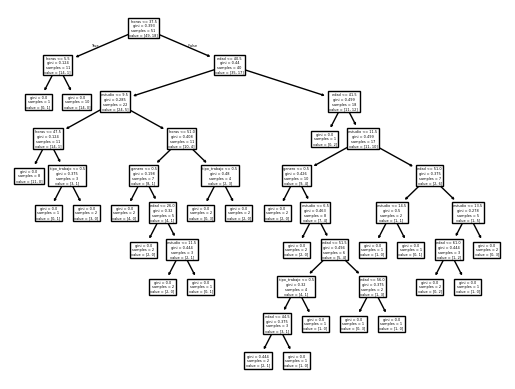

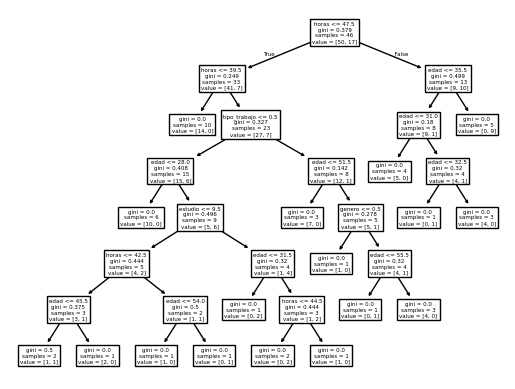

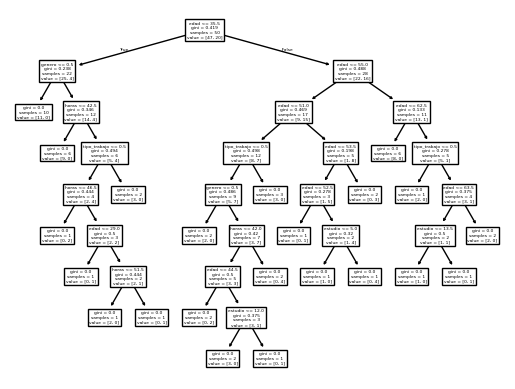

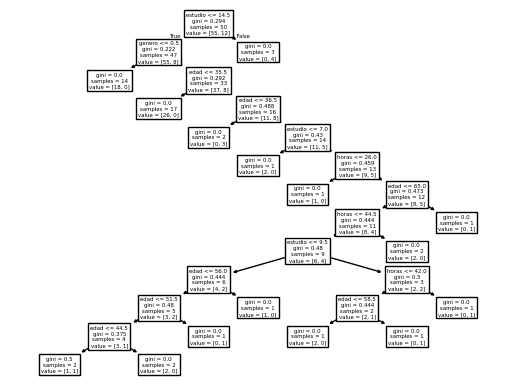

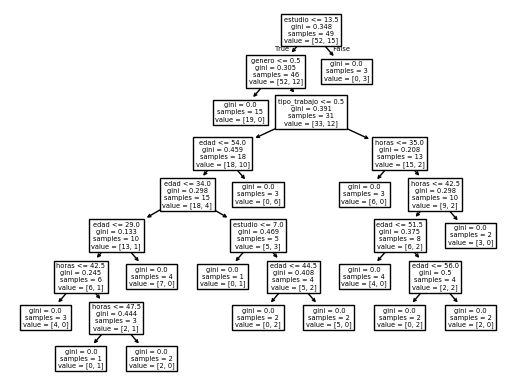

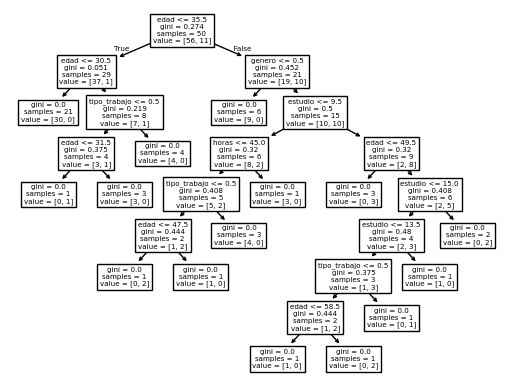

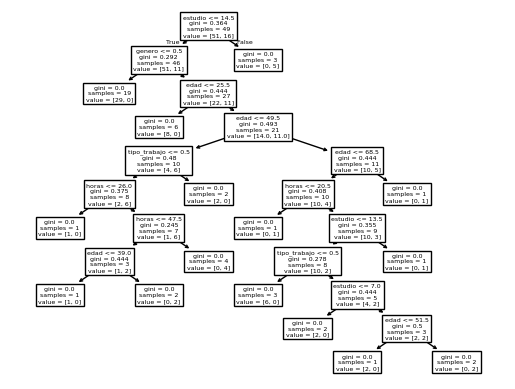

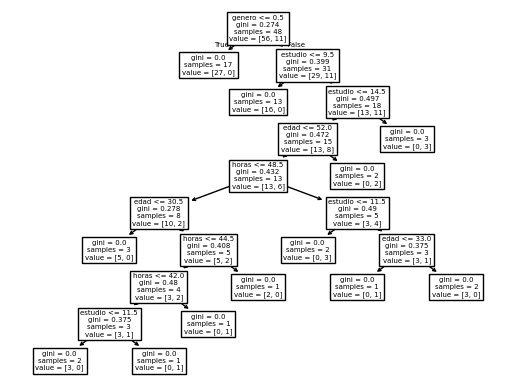

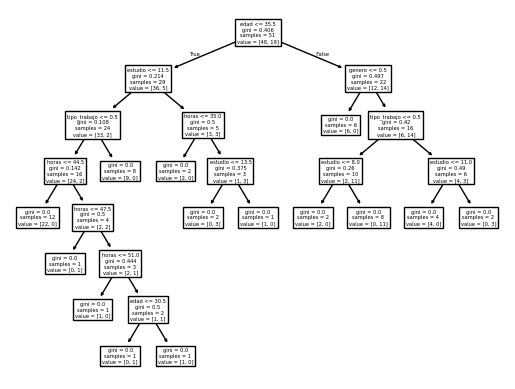

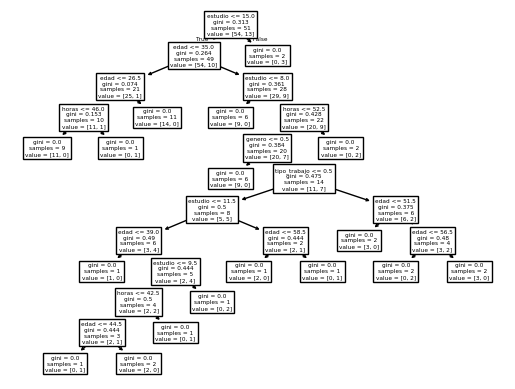

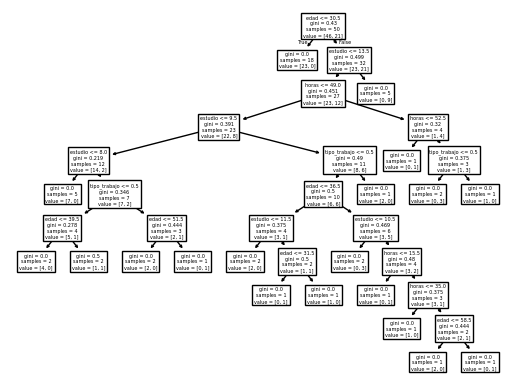

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
for arbol in bosque.estimators_:
  tree.plot_tree(arbol, feature_names=personas.columns[:-1])
  plt.show()